# Period estimation statistics

In [31]:
import requests
import time
import io
import os

import numpy as np
import pandas as pd

import rocks

from figure_mask import compute_mask, print_statistics

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("poster")

### Combination BFT & SSOFT

In [32]:
cols = [
    'sso_number', 'sso_name', 'sso_class',
    'spins.1.period.value', 'spins.2.period.value',
    'spins.1.period.error.min',
    'spins.1.period.error.max',
    'spins.1.period_type',
    'spins.1.period_flag',
    'spins.1.technique'
]

# Read BFT with rocks
bft = rocks.load_bft(columns=cols)

In [33]:
# bft[bft["spins.1.period.value"] == bft["spins.1.period.value"]].groupby("spins.1.period_flag").count()

In [34]:
print("{:,} periods available in the BFT".format(len(bft[bft["spins.1.period.value"] == bft["spins.1.period.value"]])))

47,064 periods available in the BFT


In [35]:
# You need SSOFT version 2024.09
# see fink_spins/generate_data.py
data_fink = "../../"
ssoft = pd.read_parquet(os.path.join(data_fink, "data", "ztf", "sso_ZTF.parquet"))

In [36]:
flavor = "SSHG1G2"

In [37]:
# put the period in hours
ssoft[f"{flavor}_period"] = 24 * ssoft[f"{flavor}_period"]

## Comparison to literature

In [38]:
# Keep only known periods 1 in the BFT
data = ssoft.merge(bft, left_on="name", right_on="sso_name", how="left")
data = data[data["spins.1.period.value"] == data["spins.1.period.value"]]

# sort by number of observations
data = data.sort_values("n_obs", ascending=False)
# data = data.sort_values(f'{flavor}_rms', ascending=False)

col_display = ["sso_number", "sso_name", "n_obs", "sso_class", "spins.1.period.value", "spins.2.period.value", f"{flavor}_period", 'spins.1.technique']
col_display = ["sso_number", "sso_name", "n_obs", "sso_class", "spins.1.period.value", f"{flavor}_period", 'spins.1.technique', f'{flavor}_rms']

if flavor == 'SHG1G2':
    col_display.append(f"{flavor}_R")

cond = data.sso_class.str.contains("Inner")
cond = (data['spins.1.technique']=='LCI') & ( np.abs(data['spins.1.period.value']-data['SSHG1G2_period']) < 0.1)

data.loc[cond,col_display].head(50)

,sso_number,sso_name,n_obs,sso_class,spins.1.period.value,SSHG1G2_period,spins.1.technique,SSHG1G2_rms
137853,22149,2000 WD49,517.0,Trojan>L4,6.751700,6.753919,LCI,0.076883
84369,4209,Briggs,508.0,MB>Outer,12.252700,12.250152,LCI,0.074591
33629,1437,Diomedes,490.0,Trojan>L4,24.498000,24.500024,LCI,0.057586
119466,19844,2000 ST317,475.0,Trojan>L5,14.542000,14.543977,LCI,0.110728
53577,5209,Oloosson,462.0,Trojan>L4,11.602700,11.604052,LCI,0.050172
115169,761,Brendelia,453.0,MB>Outer,57.995000,57.919241,LCI,0.048465
25118,265,Anna,435.0,Phocaea,11.690300,11.682778,LCI,0.193730
53464,18063,1999 XW211,432.0,Trojan>L4,39.557000,39.540968,LCI,0.068720
4640,2456,Palamedes,430.0,Trojan>L4,7.252200,7.252544,LCI,0.060164
48154,2528,Mohler,426.0,MB>Outer,6.491300,6.491296,LCI,0.298781


In [39]:
print("{:,} periods available in the BFT x Fink".format(len(data[data["spins.1.period.value"] == data["spins.1.period.value"]])))

34,302 periods available in the BFT x Fink


### Mask

It is not obvious yet what are the criteria for good period estimation, so let's stick with masks defined for sHG1G2

In [40]:
mask_SHG1G2_union = compute_mask(data, model='SHG1G2', kind='union')
mask_HG1G2_union = compute_mask(data, model='HG1G2', kind='union')
mask_HG_union = compute_mask(data, model='HG', kind='union')

mask_SHG1G2_inter = compute_mask(data, model='SHG1G2', kind='inter')
mask_HG1G2_inter = compute_mask(data, model='HG1G2', kind='inter')
mask_HG_inter = compute_mask(data, model='HG', kind='inter')

maskFINK_inter = compute_mask(data, R_min=0.305, model='FINK', kind='inter')
maskFINK_union = compute_mask(data, R_min=0.305, model='FINK', kind='union')

for model in ['HG', 'HG1G2', 'SHG1G2', 'FINK']:
    print_statistics(data, model)
    print()

  All data       :  34302  (100.00%)
  Mask HG (g∩r) :  33780  ( 98.48%)
  Mask HG (gUr) :  33781  ( 98.48%)

  All data       :  34302  (100.00%)
  Mask HG1G2 (g∩r) :  13264  ( 38.67%)
  Mask HG1G2 (gUr) :  24344  ( 70.97%)

  All data       :  34302  (100.00%)
  Mask SHG1G2 (g∩r) :  18561  ( 54.11%)
  Mask SHG1G2 (gUr) :  27922  ( 81.40%)

  All data       :  34302  (100.00%)
  Mask FINK (g∩r) :  18262  ( 53.24%)
  Mask FINK (gUr) :  27385  ( 79.83%)



In [41]:
# We choose mask union
mask = maskFINK_union

In [42]:
print("{:,} periods available in the MASK(BFT x Fink)".format(
    len(data[data["spins.1.period.value"] == data["spins.1.period.value"]][mask])))

23,053 periods available in the MASK(BFT x Fink)


### Period distribution

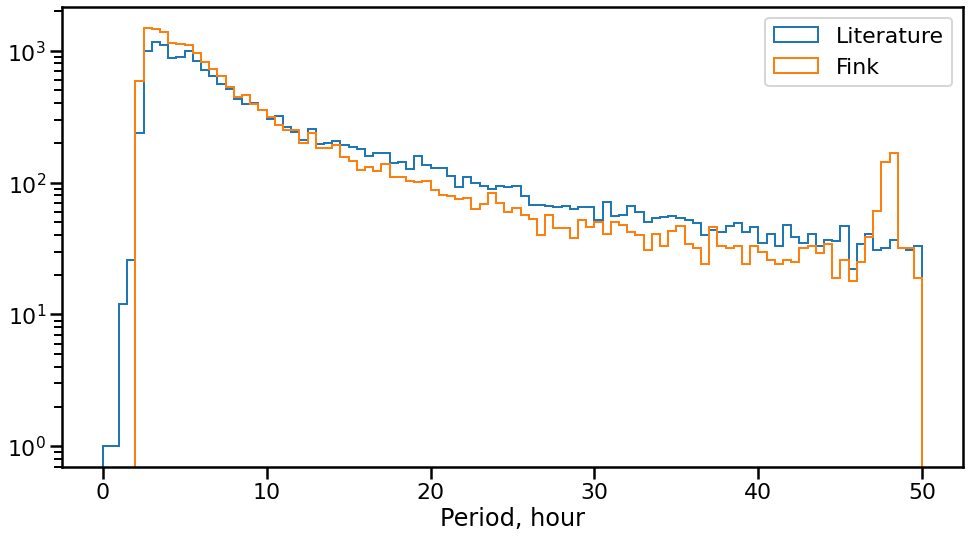

In [43]:
fig = plt.figure(figsize=(14, 8))

xmax = 50

_, bins, _ = plt.hist(
    data[mask]["spins.1.period.value"], 
    density=False, 
    bins=100, 
    range=(0, xmax), 
    histtype="step",
    label="Literature"
)
plt.hist(
    data[mask][f"{flavor}_period"], 
    density=False, 
    bins=bins, 
    range=(0, xmax), 
    histtype="step",
    label="Fink"
)
plt.legend()
plt.yscale("log")
plt.xlabel("Period, hour")
plt.tight_layout()

General trend is OK. Fink has more small periods than in the literature (few hours). A large bump at `P=24h` which is not-so-suprising given the general cadence of ZTF...

## 24 hours bump

This seems clearly an artifact from the cadence. Let's try to correlate this bump with other parameters:

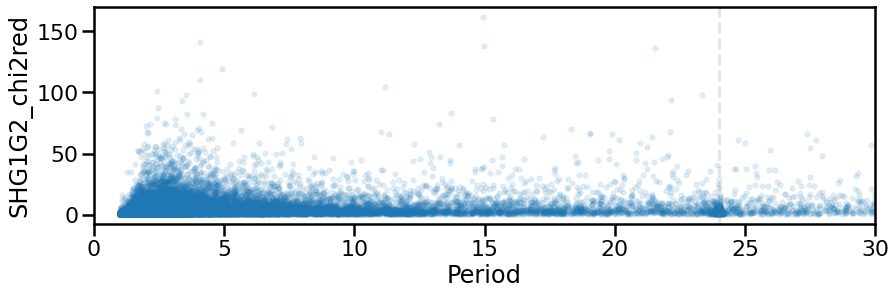

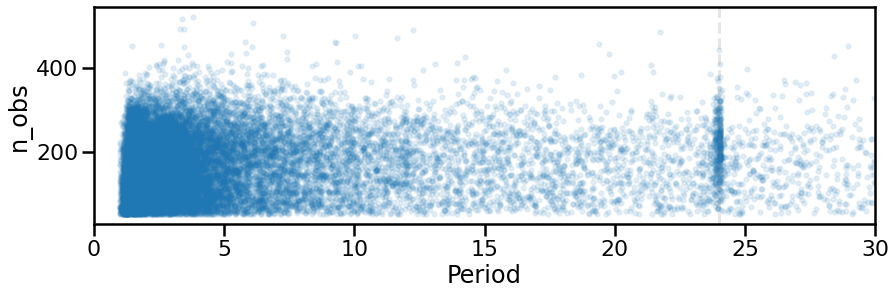

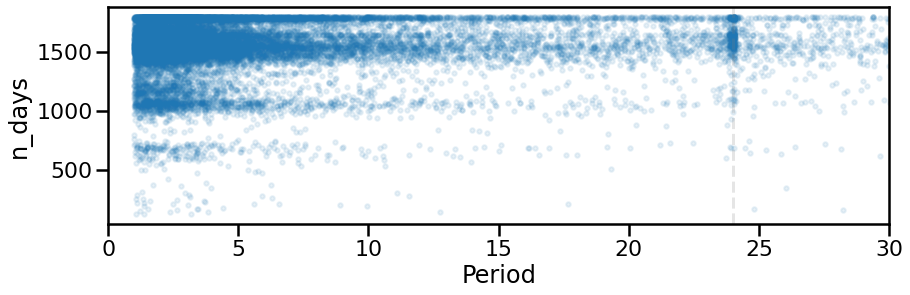

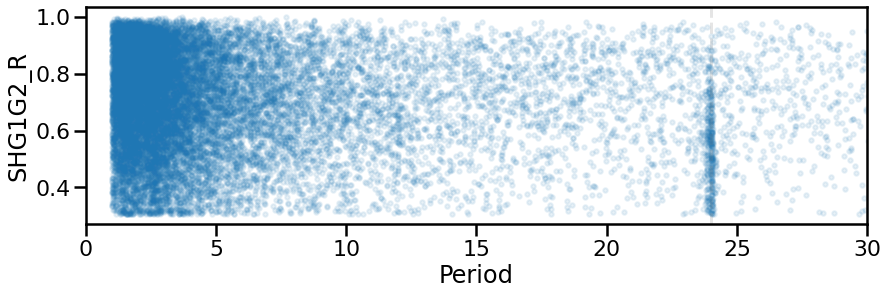

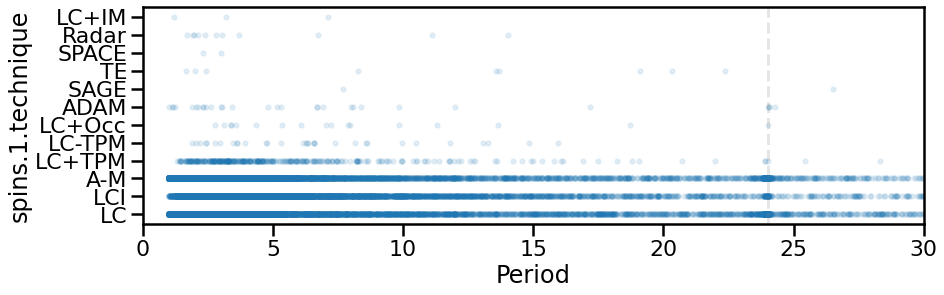

In [44]:
vals = ["SHG1G2_chi2red", "n_obs", "n_days", "SHG1G2_R", "spins.1.technique"]

for val in vals:
    fig = plt.figure(figsize=(14, 4))

    plt.scatter(data[mask]["SHG1G2_synodic_period"], data[mask][val], alpha=0.1, s=20)
    plt.axvline(24, ls='--', color='grey', alpha=0.2)
    plt.ylabel(val)
    plt.xlabel("Period")
    plt.xlim(0, 30)
    plt.show()

Nothing really correlated. We should probe the lightcurve morphology (number of opposition, real cadence, ...)

## Scatter plot

Let's compare directly periods:

In [45]:
def alias_func(x, i, j, p_feat):
    """ Return aliases relation

    x: float
        Fink period
    i: int
        Strictly positive integer. Mode.
    j: int
        Alias
    p_feat: float
        Frequency of a feature
    """
    return (i + 1) * p_feat * x / np.abs(p_feat - j *x)

/tmp/ipykernel_367432/1958375727.py:13: RuntimeWarning: divide by zero encountered in divide
  return (i + 1) * p_feat * x / np.abs(p_feat - j *x)


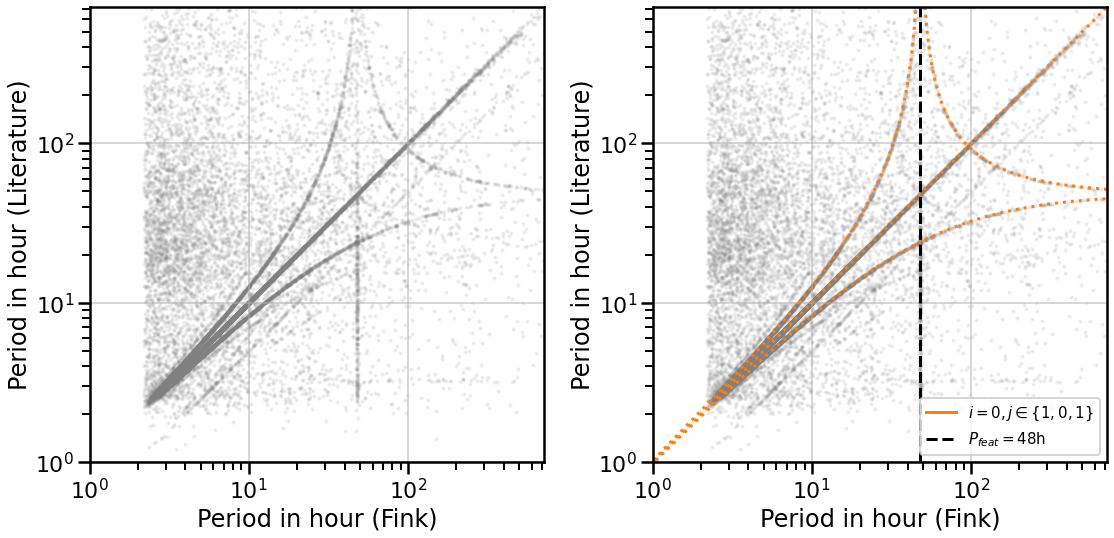

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

maxval = 30*24

for ax in axes:
    ax.scatter(
        data[mask][f"{flavor}_period"],
        data[mask]["spins.1.period.value"], 
        marker='.', alpha=0.1, s=20, color='grey'
    )
    # plt.colorbar()
    ax.grid(alpha=0.5)
    ax.set_xlim(1, maxval)
    ax.set_ylim(1, maxval)
    ax.set_xlabel("Period in hour (Fink)")
    ax.set_ylabel("Period in hour (Literature)")
    ax.set_xscale("log")
    ax.set_yscale("log")

xr = np.array(range(maxval))

axes[1].plot(0.1, 0.1, color="C1", label=r"$i=0, j \in \{1, 0, 1 \}$") # For the legend
# axes[1].plot(0.1, 0.1, color="C2", label=r"$i=1, j \in \{-2, 1, 0, 1, 2 \}$") # For the legend

for i in [0]:
    for j in range(-1, 2):
        axes[1].plot(xr, alias_func(xr, i, j, p_feat=48), color='C{}'.format(i+1), ls=':', label="")
axes[1].axvline(48, ls='--', color='black', label=r"$P_{feat} = 48$h")
# axes[1].axvline(24, ls=':', color='black', label=r"$P_{feat} = 24$h")

axes[1].legend(prop={'size': 15})
plt.tight_layout()

The left plot shows strong features that are actually related to aliases of the fundamental and harmonics of the true period. They are easily parametrized using:

$$
\dfrac{1}{P_{Fink}} = \Big | \dfrac{i + 1}{P_{true}} + \dfrac{j}{P_{feat}} \Big |
$$

or

$$
P_{i, j} = \dfrac{(i + 1)\times P_{feat} \times P_{Fink}}{|P_{feat} - j \times P_{Fink}|}
$$

where $P_{feat}$ is the period of an instrumental effect rooted in the structure of the window function of the signal (e.g. the cadence), $P_{Fink}$ is the best fit period from Fink data, $i$ is a positive integer related to harmonics, and $j$ is an integer related to aliases of the fundamental ($i=0$) and its harmonics ($i>0$). In the plot above the case for $P_{feat} = 24h$, $i \in \{0, 1\}$ and $j \in \{-2, 1, 0, 1, 2\}$ is shown. Some interesting cases clearly seen on the plot:
- $i=0, j=0$: fundamental
- $i=1, j=0$: first harmonics
- $i=1, j=\pm 1$: aliases of the first harmonics

In [49]:
data[mask][np.isclose(data[mask][f"{flavor}_period"], data[mask]["spins.1.period.value"], 1e-1)]

,ssnamenr,HG_chi2red,HG_status,HG_fit,HG_rms,HG_rms_g,HG_rms_r,HG_median_error_phot,HG_median_error_phot_1,HG_median_error_phot_2,...,sso_number,sso_name,sso_class,spins.1.period.value,spins.2.period.value,spins.1.period.error.min,spins.1.period.error.max,spins.1.period_type,spins.1.period_flag,spins.1.technique
137853,22149,5.992198,2.0,0.0,0.137289,0.142524,0.134073,0.065484,0.070952,0.060745,...,22149,2000 WD49,Trojan>L4,6.751700,NaN,-0.000100,0.000100,sidereal,None,LCI
84369,4209,19.879328,2.0,0.0,0.185987,0.183811,0.187140,0.044664,0.044515,0.044862,...,4209,Briggs,MB>Outer,12.252700,12.252700,-0.000200,0.000200,Sidereal,None,LCI
98854,911,38.913219,2.0,0.0,0.168672,0.175298,0.164634,0.029524,0.030096,0.028997,...,911,Agamemnon,Trojan>L4,6.581780,6.581800,-1.000000,1.000000,Sidereal,None,LC+TPM
86588,624,102.214050,2.0,0.0,0.259976,0.208263,0.288384,0.028400,0.029661,0.027315,...,624,Hektor,Trojan>L4,6.920509,6.920510,-0.000005,0.000005,Sidereal,Quality of the period not rated.,LC-TPM
33629,1437,44.677925,2.0,0.0,0.201178,0.191102,0.206902,0.032047,0.033548,0.030626,...,1437,Diomedes,Trojan>L4,24.498000,24.501000,-0.001000,0.001000,sidereal,None,LCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94000,59180,0.859325,2.0,0.0,0.109636,0.115939,0.105586,0.136648,0.158406,0.122939,...,59180,1999 AP12,MB>Inner,7.745128,7.745128,-0.026379,0.026379,Synodic,Quality of the period not rated.;Quality of th...,A-M
58794,79272,6.592896,2.0,0.0,0.271787,0.259168,0.282935,0.127375,0.146153,0.103726,...,79272,1995 SN6,MB>Inner,7.741692,7.741692,-0.063372,0.063372,Synodic,Quality of the period not rated.,A-M
93699,190637,1.663444,2.0,0.0,0.129997,0.136117,0.125752,0.120405,0.139355,0.097525,...,190637,2000 WE155,MB>Middle,9.350000,NaN,-0.030000,0.030000,Synodic,U=2,LC
16262,198582,3.487261,4.0,0.0,0.198026,0.165145,0.206354,0.142856,0.144585,0.141178,...,198582,2004 YT13,MB>Outer,233.131000,NaN,-7.313900,7.313900,Synodic,U=2,LC


### More reliable flags

In [50]:
# Choosing only reliable flags
mask_pure = mask * data["spins.1.period_flag"].isin(["U=1", "U=2", "U=3", "U=1+", "U=2+", "U=3+", "U=1-", "U=2-", "U=3-"])

/tmp/ipykernel_367432/1958375727.py:13: RuntimeWarning: divide by zero encountered in divide
  return (i + 1) * p_feat * x / np.abs(p_feat - j *x)


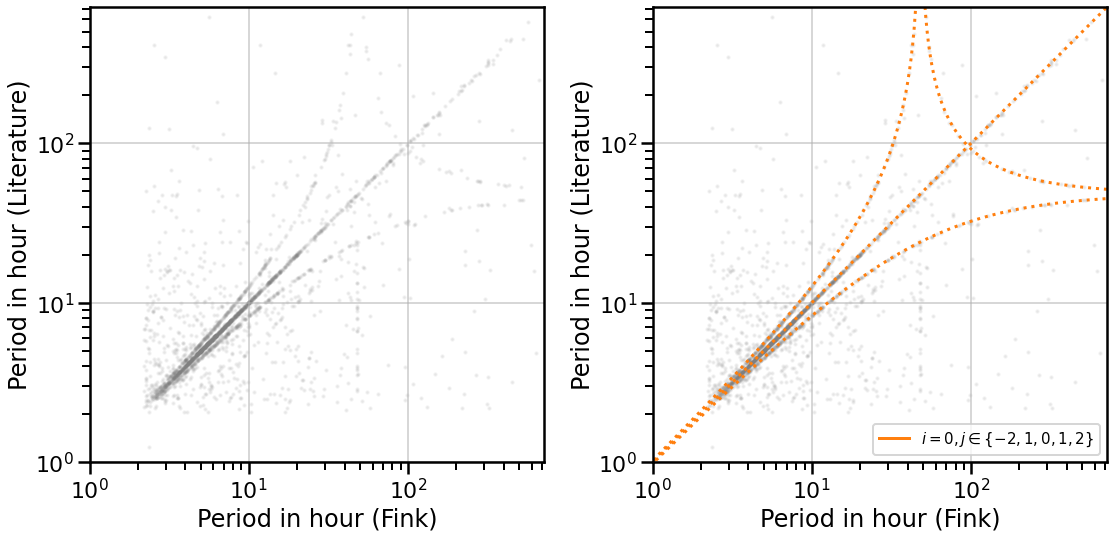

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

maxval = 30*24

for ax in axes:
    ax.scatter(
        data[mask_pure][f"{flavor}_period"], 
        data[mask_pure]["spins.1.period.value"], 
        marker='.', alpha=0.1, s=20, color='grey'
    )
    # plt.colorbar()
    ax.grid(alpha=0.5)
    ax.set_xlim(1, maxval)
    ax.set_ylim(1, maxval)
    ax.set_xlabel("Period in hour (Fink)")
    ax.set_ylabel("Period in hour (Literature)")
    ax.set_xscale("log")
    ax.set_yscale("log")

xr = np.array(range(maxval))

axes[1].plot(0.1, 0.1, color="C1", label=r"$i=0, j \in \{-2, 1, 0, 1, 2 \}$") # For the legend
# axes[1].plot(0.1, 0.1, color="C2", label=r"$i=1, j \in \{-2, 1, 0, 1, 2 \}$") # For the legend

for i in [0]:
    for j in range(-1, 2):
        axes[1].plot(xr, alias_func(xr, i, j, p_feat=48), color='C{}'.format(i+1), ls=':', label="")
# axes[1].axvline(24, ls=':', color='black', label=r"$P_{feat} = 48$h")

axes[1].legend(prop={'size': 15})
plt.tight_layout()

## Aliases vs mismatches

Let's count how many Fink period are just harmonics or aliases of the literature periods, and how many are mismatching:

In [54]:
from collections import Counter

def is_alias(obs, true, p_feat):
    for i in [0, 1]:
        for j in range(-2, 3):
            tmp = alias_func(obs, i, j, p_feat)
            if np.isclose(tmp, true, 1e-1):
                return "{},{}".format(i, j)
    return ""

def is_feature(obs, p_feat):
    if np.isclose(obs, p_feat, 1e-1):
        return True
    return False

In [55]:
tmp = [is_alias(obs, true, p_feat=48) for obs, true in zip(data[mask][f"{flavor}_period"], data[mask]["spins.1.period.value"])]
d = Counter(tmp)

In [56]:
matches = np.sum([d[i] for i in d if i != ""])
nfeat = np.sum([is_feature(f, 48.) for f in data[mask][f"{flavor}_period"]])

msg = "{:.2f}% are matches (true, harmonics or aliases), {:.2f}% are cadence frequency (24h period), and {:.2f}% have no match.".format(
    matches/len(tmp)*100, nfeat/len(tmp)*100, 100 - (matches + nfeat)/len(tmp)*100)
print(msg)

70.83% are matches (true, harmonics or aliases), 3.37% are cadence frequency (24h period), and 25.80% have no match.


In [57]:
true = np.sum([d[i] for i in d if i == "0,0"])
true_alias = np.sum([d[i] for i in d if i in ["0,-2", "0,-1", "0,1", "0,2"]])
first_harmonics = np.sum([d[i] for i in d if i == "1,0"])
first_harmonics_alias = np.sum([d[i] for i in d if i in ["1,-2", "1,-1", "1,1", "1,2"]])

In [58]:
msg = """
{} are exact matches (0, 0)
{} are aliases of the true frequency (0, j)
{} are the first harmonics (1, 0)
{} are aliases of the first harmonics (1, j)
{} are 48h period
""".format(true, true_alias, first_harmonics, first_harmonics_alias, nfeat)
print(msg)


7421 are exact matches (0, 0)
7904 are aliases of the true frequency (0, j)
176 are the first harmonics (1, 0)
827 are aliases of the first harmonics (1, j)
777 are 48h period



So in the end we have a strong contamination from the daily cadence of the survey. But on overall, that's 72% of the frequencies that are related to the values reported in the literature. This is a first good results as, assuming the literature is correct, we expect about the same amount of correctness in the whole Fink sample.

Note that in this first trial, the best fit period from Fink was selected as the highest peak in the periodogram. This is known to produce these artifacts. We will now move to a more robust method.